In [1]:
import rioxarray as riox
import os
import pandas as pd
import numpy as np
import geopandas as gpd
from rasterio.plot import show
import matplotlib.pyplot as plt
from hlsstack.hls_funcs.masks import shp2mask
import seaborn as sns

In [78]:
yr = 2025
inDIR = '/90daydata/cper_neon_aop/hls_nrt/gcloud/'
inFILE = f'hls_cper_{yr}_gcloud.nc'
cperPATH = 'data/pastures/cper_pastures_2025_w_carm3_zones_w_excl.shp'

In [79]:
gdf_cper = gpd.read_file(cperPATH)

In [80]:
gdf_cper = gdf_cper[gdf_cper['Treatment'].isin(['CARM Short', 'CARM Tall', 'TRM'])].copy().reset_index()

In [81]:
gdf_pasts = gdf_cper.dissolve(by='Past_Name')
gdf_pasts = gdf_pasts.reset_index()

<AxesSubplot:>

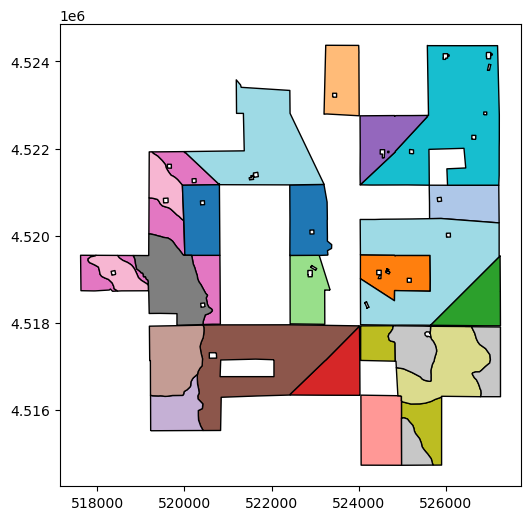

In [82]:
fig, ax = plt.subplots(figsize=(6,6))
gdf_cper.plot(ax=ax,
              column='Viewer_ID',
              cmap='tab20',
              ec='black')

<AxesSubplot:>

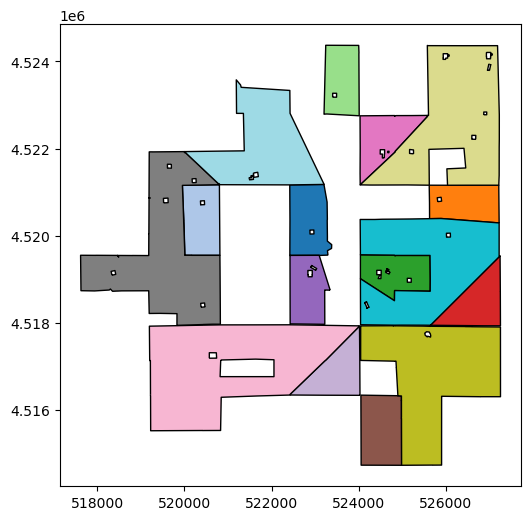

In [83]:
fig, ax = plt.subplots(figsize=(6,6))
gdf_pasts.plot(ax=ax,
              column='Past_Name',
              cmap='tab20',
              ec='black')

In [8]:
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(n_workers=48)
client = Client(cluster)
display(client)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 48
Total threads: 48,Total memory: 360.28 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45549,Workers: 48
Dashboard: http://127.0.0.1:8787/status,Total threads: 48
Started: Just now,Total memory: 360.28 GiB
Comm: tcp://127.0.0.1:34029,Total threads: 1
Dashboard: http://127.0.0.1:43469/status,Memory: 7.51 GiB
Nanny: tcp://127.0.0.1:34781,


In [84]:
ds = riox.open_rasterio(os.path.join(inDIR, inFILE), masked=True)

In [85]:
ds = ds.rio.reproject(dst_crs=gdf_cper.crs)

In [86]:
#ds['Biomass'].max()

In [87]:
ds['date'] = ds['date'].astype("datetime64[ns]")

In [88]:
mask_info = gdf_cper.rename(columns={'index': 'id'})
mask_shp = [(row.geometry, row.id+1) for _, row in mask_info.iterrows()]
subpast_mask = shp2mask(shp=mask_shp, 
                     transform=ds.rio.transform(), 
                     outshape=ds['Biomass'].shape[1:], 
                     xr_object=ds['Biomass'])
mask_dict = {row.id+1: row['Viewer_ID'] for _, row in mask_info.iterrows()}
mask_dict[0] = 'UNK'
subpast_mask = np.array([mask_dict[i] for i in subpast_mask.values.flatten()]).reshape(subpast_mask.shape)

# assign the plot id's to the xarray dataset
ds = ds.assign(subpasture=(['y', 'x'], subpast_mask))
ds = ds.set_coords('subpasture')

In [89]:
mask_info = gdf_pasts.rename(columns={'index': 'id'})
mask_shp = [(row.geometry, row.id+1) for _, row in mask_info.iterrows()]
past_mask = shp2mask(shp=mask_shp, 
                     transform=ds.rio.transform(), 
                     outshape=ds['Biomass'].shape[1:], 
                     xr_object=ds['Biomass'])
mask_dict = {row.id+1: row['Past_Name'] for _, row in mask_info.iterrows()}
mask_dict[0] = 'UNK'
past_mask = np.array([mask_dict[i] for i in past_mask.values.flatten()]).reshape(past_mask.shape)

# assign the plot id's to the xarray dataset
ds = ds.assign(pasture=(['y', 'x'], past_mask))
ds = ds.set_coords('pasture')

In [90]:
#ds.date

In [91]:
from tqdm import tqdm

In [92]:
df_pasts = None
for p in tqdm(np.unique(ds['pasture'])):
    if p != 'UNK':
        ds_tmp = ds.where(ds['pasture']==p, drop=True)
        ds_tmp['Biomass_count'] = ds_tmp['Biomass'].notnull().astype(int)
        ds_tmp_10ac = ds_tmp[['Biomass', 'BARE', 'CP', 'NDVI', 'Biomass_count']].drop_vars(['pasture', 'subpasture', 'spatial_ref']).coarsen(x=7, y=7, boundary='trim').mean(skipna=True)
        df_tmp = ds_tmp_10ac.to_dataframe().reset_index()
        df_tmp['Pasture'] = p
        if df_pasts is None:
            df_pasts = df_tmp.copy()
        else:
            df_pasts = pd.concat([df_pasts, df_tmp])

df_pasts_var = None
for p in tqdm(np.unique(ds['pasture'])):
    if p != 'UNK':
        ds_tmp = ds.where(ds['pasture']==p, drop=True)
        ds_tmp['Biomass_count'] = ds_tmp['Biomass'].notnull().astype(int)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            ds_tmp_10ac = ds_tmp[['Biomass', 'BARE', 'CP', 'NDVI', 'Biomass_count']].drop_vars(['pasture', 'subpasture', 'spatial_ref']).coarsen(x=7, y=7, boundary='trim').var(skipna=True)
        df_tmp = ds_tmp_10ac.to_dataframe().reset_index()
        df_tmp['Pasture'] = p
        if df_pasts is None:
            df_pasts_var = df_tmp.copy()
        else:
            df_pasts_var = pd.concat([df_pasts_var, df_tmp])

df_pasts_var = df_pasts_var.rename(columns={'Biomass': 'Biomass_var', 'BARE': 'BARE_var', 'CP': 'CP_var', 'NDVI': 'NDVI_var'})
df_pasts_var['date'] = pd.to_datetime(df_pasts_var['date'])
df_pasts['date'] = pd.to_datetime(df_pasts['date'])
df_pasts = pd.merge(df_pasts, gdf_pasts[['Past_Name', 'Treatment']], how='left', left_on='Pasture', right_on='Past_Name')
df_pasts = df_pasts.drop(columns=['Past_Name'])
df_pasts = pd.merge(df_pasts, 
         df_pasts_var.drop(columns=['Biomass_count']), how='left', on=['date', 'y', 'x', 'Pasture'])

100%|██████████| 17/17 [00:13<00:00,  1.27it/s]


In [93]:
df_subpasts = None
for sp in tqdm(np.unique(ds['subpasture'])):
    if sp != 'UNK':
        ds_tmp = ds.where(ds['subpasture']==sp, drop=True)
        ds_tmp['Biomass_count'] = ds_tmp['Biomass'].notnull().astype(int)
        ds_tmp_10ac = ds_tmp[['Biomass', 'BARE', 'CP', 'NDVI', 'Biomass_count']].drop_vars(['pasture', 'subpasture', 'spatial_ref']).coarsen(x=7, y=7, boundary='trim').mean(skipna=True)
        df_tmp = ds_tmp_10ac.to_dataframe().reset_index()
        df_tmp['SubPasture'] = sp
        if df_subpasts is None:
            df_subpasts = df_tmp.copy()
        else:
            df_subpasts = pd.concat([df_subpasts, df_tmp])

df_subpasts_var = None
for sp in tqdm(np.unique(ds['subpasture'])):
    if sp != 'UNK':
        ds_tmp = ds.where(ds['subpasture']==sp, drop=True)
        ds_tmp['Biomass_count'] = ds_tmp['Biomass'].notnull().astype(int)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            ds_tmp_10ac = ds_tmp[['Biomass', 'BARE', 'CP', 'NDVI', 'Biomass_count']].drop_vars(['pasture', 'subpasture', 'spatial_ref']).coarsen(x=7, y=7, boundary='trim').var(skipna=True)
        df_tmp = ds_tmp_10ac.to_dataframe().reset_index()
        df_tmp['SubPasture'] = sp
        if df_subpasts is None:
            df_subpasts_var = df_tmp.copy()
        else:
            df_subpasts_var = pd.concat([df_subpasts_var, df_tmp])

df_subpasts_var = df_subpasts_var.rename(columns={'Biomass': 'Biomass_var', 'BARE': 'BARE_var', 'CP': 'CP_var', 'NDVI': 'NDVI_var'})
df_subpasts_var['date'] = pd.to_datetime(df_subpasts_var['date'])
df_subpasts['date'] = pd.to_datetime(df_subpasts['date'])
df_subpasts = pd.merge(df_subpasts, gdf_cper[['Viewer_ID', 'Treatment']], how='left', left_on='SubPasture', right_on='Viewer_ID')
df_subpasts = df_subpasts.drop(columns=['Viewer_ID'])
df_subpasts = pd.merge(df_subpasts, 
                       df_subpasts_var.drop(columns=['Biomass_count']), how='left', on=['date', 'y', 'x', 'SubPasture'])

100%|██████████| 23/23 [00:17<00:00,  1.31it/s]


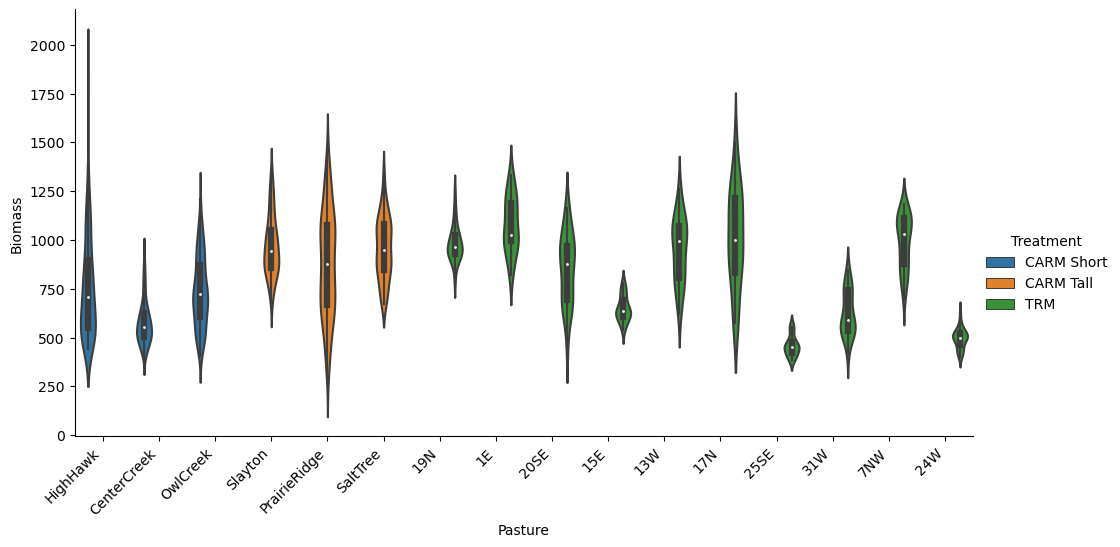

In [94]:
sns.catplot(kind='violin', y='Biomass', x='Pasture', hue='Treatment', 
            data=df_pasts[df_pasts['date'] == pd.to_datetime(f'{yr}-06-20')].sort_values('Treatment'), 
            aspect=2.0, sharex=False)
plt.gca().set_xticklabels(plt.gca().get_xticklabels(), rotation=45, horizontalalignment='right')
plt.savefig(f'data/products/heterogeneity/carm3_pasture_biomass_{yr}_june20.png', dpi=150, bbox_inches='tight')

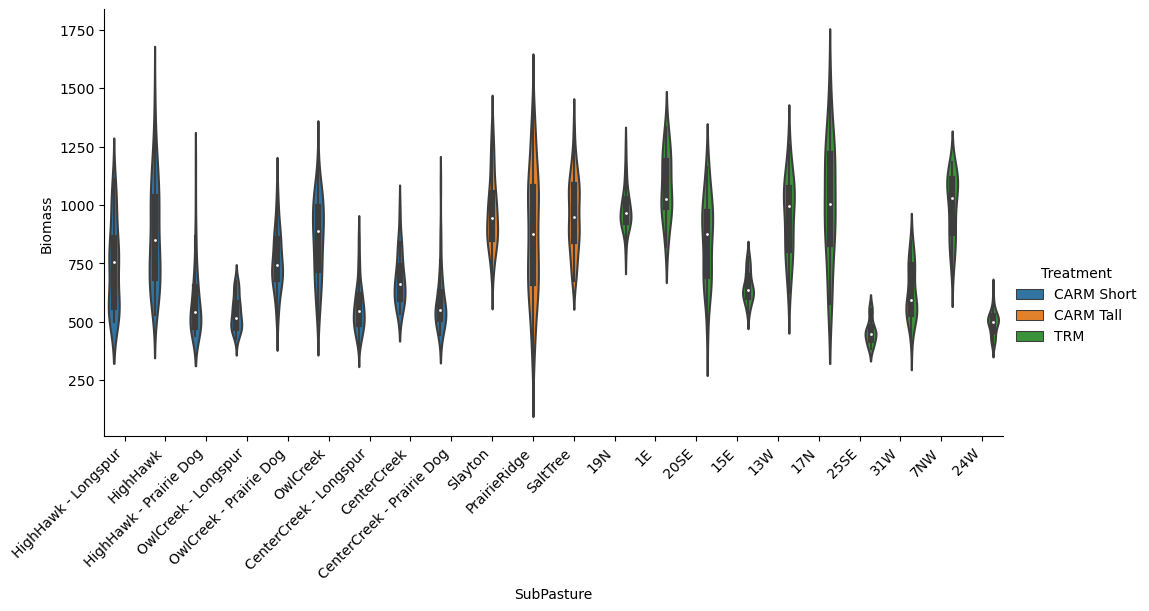

In [95]:
sns.catplot(kind='violin', y='Biomass', x='SubPasture', hue='Treatment', 
            data=df_subpasts[df_subpasts['date'] == pd.to_datetime(f'{yr}-06-20')].sort_values('Treatment'), 
            aspect=2.0, sharex=False)
plt.gca().set_xticklabels(plt.gca().get_xticklabels(), rotation=45, horizontalalignment='right')
plt.savefig(f'data/products/heterogeneity/carm3_subpasture_biomass_{yr}_june20.png', dpi=150, bbox_inches='tight')

In [96]:
df_pasts.to_csv(f'data/products/heterogeneity/carm3_pasture_means_7x7grid_{yr}.csv', index=False)
df_subpasts.to_csv(f'data/products/heterogeneity/carm3_subpasture_means_7x7grid_{yr}.csv', index=False)

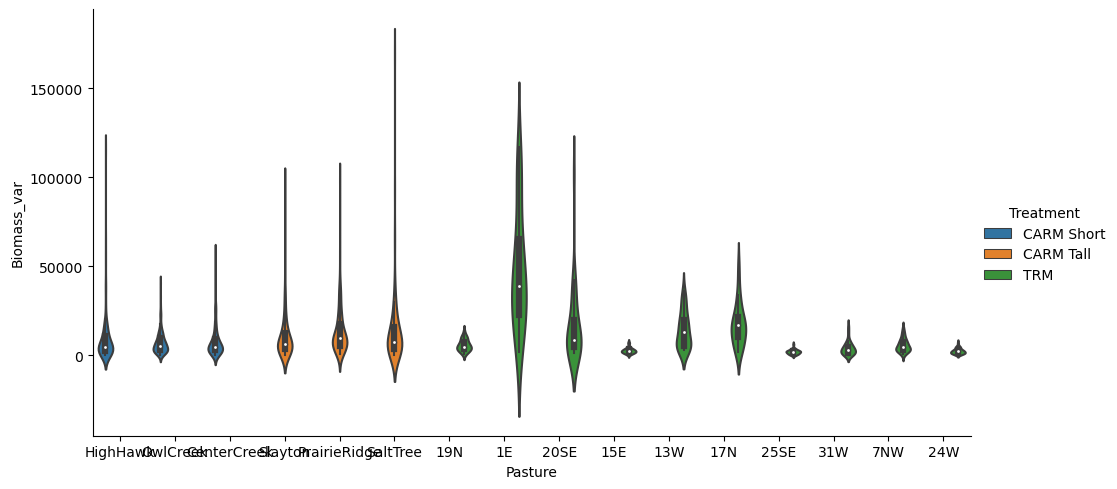

In [59]:
sns.catplot(kind='violin', y='Biomass_var', x='Pasture', hue='Treatment', 
            data=df_pasts[df_pasts['date'] == pd.to_datetime('2024-06-20')].sort_values('Treatment'), 
            aspect=2.0, sharex=False)

In [22]:
import dask.dataframe as dd
import warnings

# Convert Pandas DataFrame to Dask (npartitions should match CPU cores)
ddf_pasts = dd.from_pandas(df_pasts, npartitions=48)


In [23]:
ddf_pasts

,date,y,x,Biomass,BARE,CP,NDVI,Biomass_count,Pasture,Treatment
npartitions=48,,,,,,,,,,
0,datetime64[ns],float64,float64,float32,float32,float32,float32,float64,object,object
23707,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...
1114188,...,...,...,...,...,...,...,...,...,...
1137893,...,...,...,...,...,...,...,...,...,...


In [24]:
def silent_var(x):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # Your specific logic that triggers the warning
        return np.std(x)

def silent_relvar(x):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # Your specific logic that triggers the warning
        return np.var(x) / (np.mean(x)**2)

In [25]:
df_pasts_var = ddf_pasts.groupby(
    ['Treatment', 'Pasture', 'date']).apply(
    lambda data: silent_var(data.drop(columns=['date', 'y', 'x'])), meta=df_pasts.drop(columns=['Pasture', 'Treatment', 'date', 'y', 'x'])).compute()

In [26]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    df_pasts_relvar = ddf_pasts.groupby(
        ['Treatment', 'Pasture', 'date']).apply(
        lambda data: silent_relvar(data.drop(columns=['date', 'y', 'x'])), meta=df_pasts.drop(columns=['Pasture', 'Treatment', 'date', 'y', 'x'])).compute()

In [27]:
df_pasts_var = df_pasts_var.reset_index().sort_values(['Pasture', 'date'])
df_pasts_relvar = df_pasts_relvar.reset_index().sort_values(['Pasture', 'date'])

/local/scratch/sean.kearney/19527434/ipykernel_2566109/842300894.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.catplot(kind='point', x='date', y='Biomass', col='Treatment', data=df_pasts,


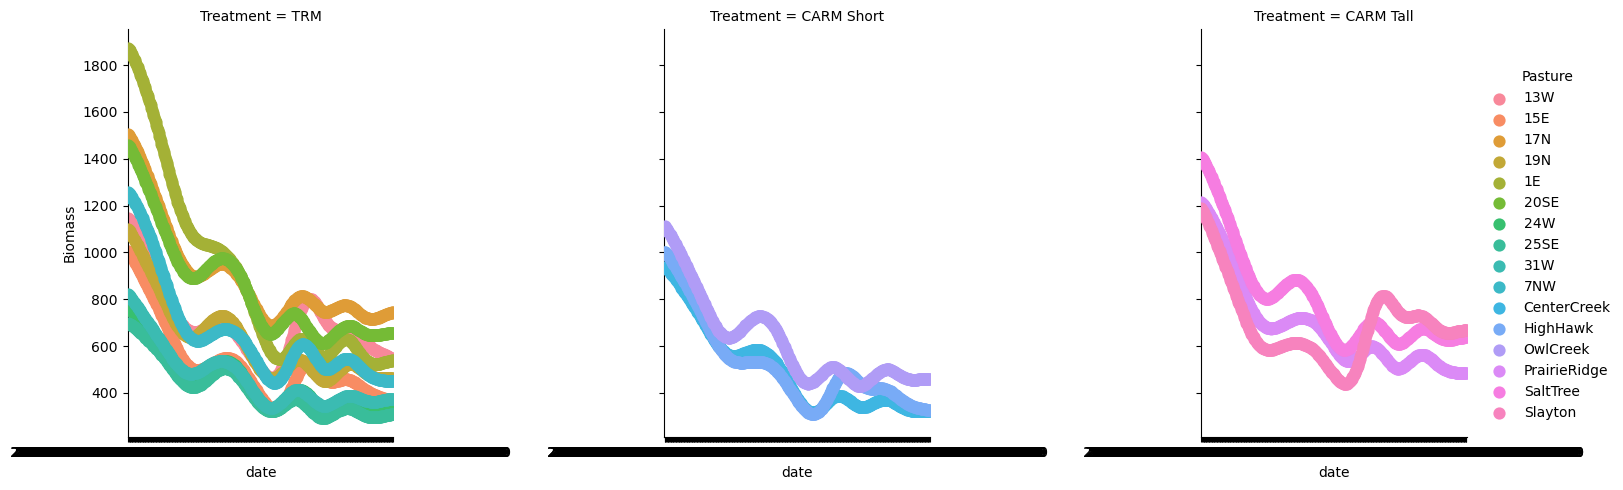

In [36]:
sns.catplot(kind='point', x='date', y='Biomass', col='Treatment', data=df_pasts,
            hue='Pasture', errorbar=None)

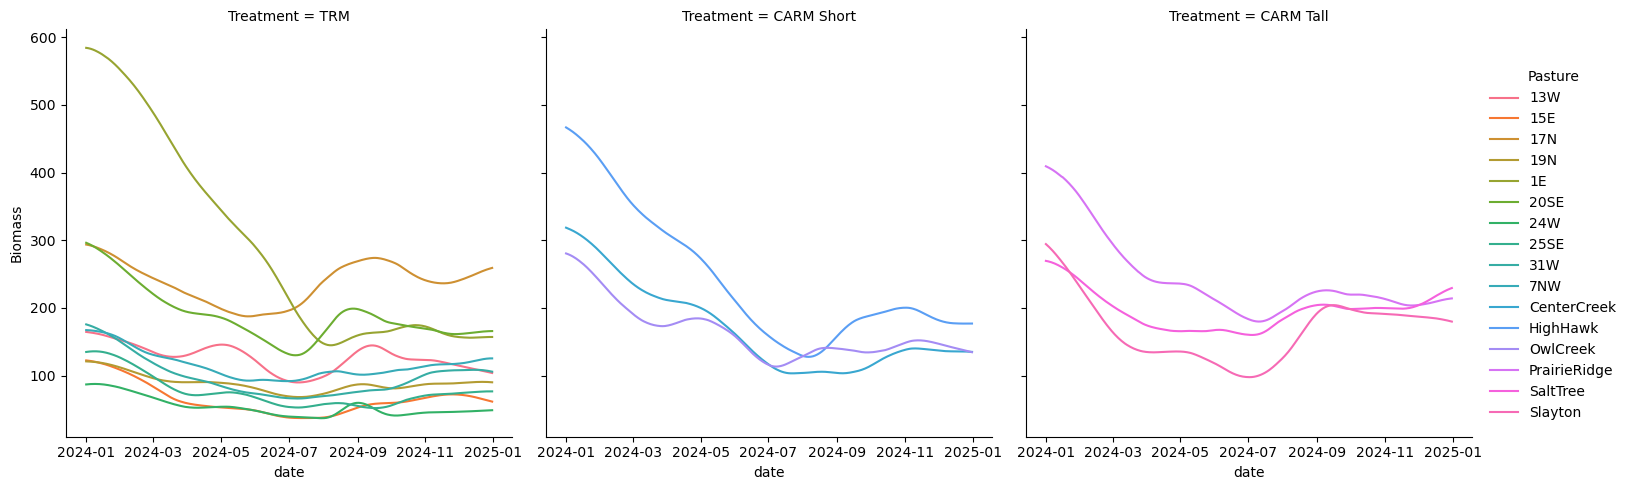

In [28]:
sns.relplot(kind='line', x='date', y='Biomass', col='Treatment', data=df_pasts_var,
            hue='Pasture')

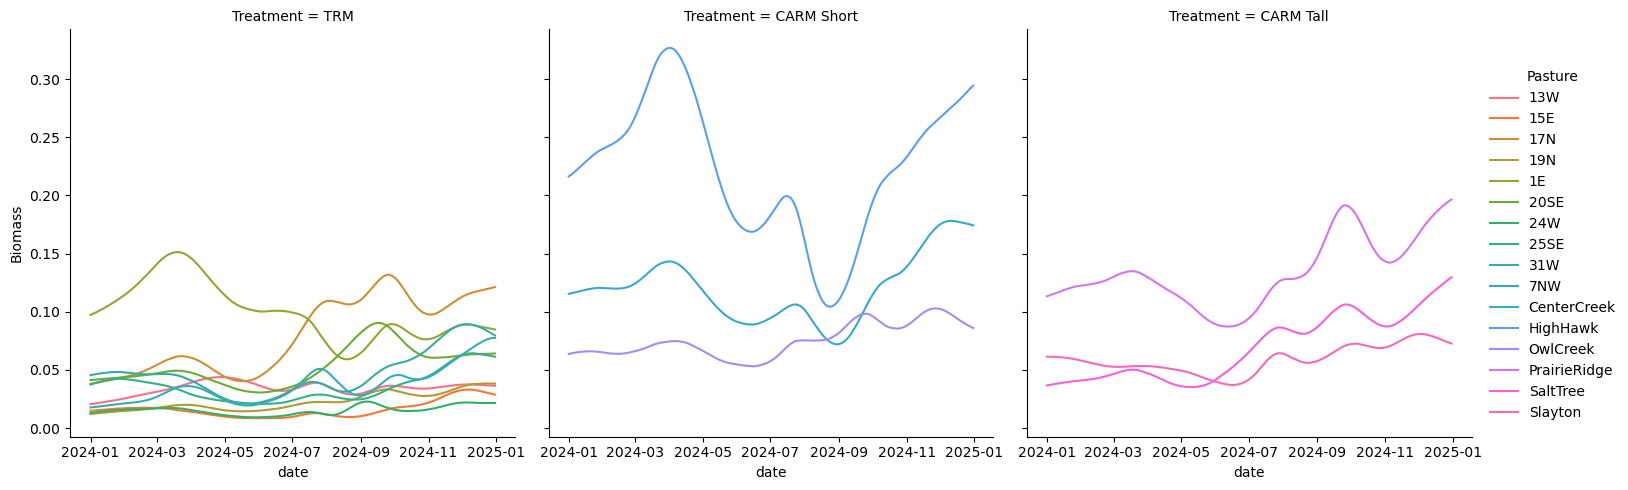

In [29]:
sns.relplot(kind='line', x='date', y='Biomass', col='Treatment', data=df_pasts_relvar,
            hue='Pasture')

In [306]:
gdf_cper.columns

Index(['index', 'OBJECTID_1', 'Join_Count', 'TARGET_FID', 'Past_Name',
       'CARM_Past', 'old_Past_N', 'Ownership', 'Treatment', 'Replicate',
       'Field', 'Shape_Leng', 'Shape_Area', 'Acres', 'Ha', 'Shape_Le_1',
       'Shape_Le_2', 'layer', 'path', 'Viewer_ID', 'geometry'],
      dtype='object')

In [157]:
ds_10ac = ds.coarsen(x=7, y=7, boundary='trim').mean()

In [158]:
ds_10ac = ds_10ac.rio.write_transform()

In [161]:
ds_10ac

<xarray.Dataset>
Dimensions:        (date: 366, y: 46, x: 46)
Coordinates:
  * x              (x) float64 5.177e+05 5.179e+05 ... 5.269e+05 5.271e+05
  * y              (y) float64 4.524e+06 4.524e+06 ... 4.515e+06 4.515e+06
  * date           (date) object 2024-01-01 00:00:00 ... 2024-12-31 00:00:00
    spatial_ref    int64 0
    subpasture     (y, x) <U25 'UNK' 'UNK' 'UNK' 'UNK' ... 'UNK' 'UNK' 'UNK'
    pasture        (y, x) <U12 'UNK' 'UNK' 'UNK' 'UNK' ... 'UNK' 'UNK' 'UNK'
Data variables:
    BARE           (date, y, x) float32 0.2858 0.241 0.2638 ... 0.1891 0.1436
    NONVEG         (date, y, x) float32 0.3439 0.2863 0.3429 ... 0.3749 0.3274
    GREEN          (date, y, x) float32 0.1867 0.1977 0.1499 ... 0.09936 0.1295
    SD             (date, y, x) float32 0.4694 0.516 0.5071 ... 0.5257 0.543
    LITT           (date, y, x) float32 0.05808 0.0453 0.07915 ... 0.1859 0.1838
    Biomass        (date, y, x) float32 589.5 682.5 534.6 ... 448.7 591.1 708.0
    Biomass_SE     (date, y, x) float32 138.9 139.8 137.1 ... 142.0 137.3 138.1
    NDVI           (date, y, x) float32 0.1915 0.1968 0.1916 ... 0.1733 0.1844
    CP             (date, y, x) float32 nan nan nan nan ... 6.506 6.9 6.568
    DRYVEG         (date, y, x) float32 0.5275 0.5613 0.5863 ... 0.7115 0.7268
    Biomass_count  (date, y, x) float64 0.7347 0.8571 0.8571 ... 1.0 1.0 1.0
Attributes:
    _FillValue:  3.402823466385289e+38

In [163]:
#ds_test = ds_10ac.sel(date='2025-06-20').chunk({'y': 5, 'x': 5})

In [164]:
df_10ac = ds_10ac.chunk({'y': 50, 'x': 50})[['Biomass', 'BARE', 'CP', 'NDVI', 'Biomass_count']].to_dataframe()

In [167]:
df_10ac = df_10ac[df_10ac['pasture'] != 'UNK'].copy().reset_index()

In [168]:
df_10ac = pd.merge(df_10ac, gdf_cper[['Past_Name', 'Treatment']], how='left', left_on='pasture', right_on='Past_Name')

In [187]:
df_10ac

,date,y,x,Biomass,BARE,CP,NDVI,Biomass_count,spatial_ref,subpasture,pasture,Past_Name,Treatment
0,2024-01-01 00:00:00,4.524329e+06,523327.015854,1935.095825,0.153584,NaN,0.275140,0.857143,0,1E,1E,1E,TRM
1,2024-01-01 00:00:00,4.524329e+06,523537.017540,1628.078125,0.156140,NaN,0.250894,0.857143,0,1E,1E,1E,TRM
2,2024-01-01 00:00:00,4.524329e+06,523747.019225,1157.368164,0.192696,NaN,0.225059,0.857143,0,1E,1E,1E,TRM
3,2024-01-01 00:00:00,4.524329e+06,523957.020910,899.303223,0.229301,NaN,0.208103,0.857143,0,1E,1E,1E,TRM
4,2024-01-01 00:00:00,4.524329e+06,525637.034392,1484.209351,0.178015,NaN,0.253647,0.857143,0,PrairieRidge,PrairieRidge,PrairieRidge,CARM Tall
...,...,...,...,...,...,...,...,...,...,...,...,...,...
721015,2024-12-31 00:00:00,4.514879e+06,525637.034392,258.239624,0.249903,6.374177,0.153769,1.000000,0,OwlCreek,OwlCreek,OwlCreek,CARM Short
721016,2024-12-31 00:00:00,4.514879e+06,525637.034392,258.239624,0.249903,6.374177,0.153769,1.000000,0,OwlCreek,OwlCreek,OwlCreek,CARM Short
721017,2024-12-31 00:00:00,4.514879e+06,525847.036078,144.568802,0.379173,6.940223,0.154164,1.000000,0,OwlCreek - Longspur,OwlCreek,OwlCreek,CARM Short
721018,2024-12-31 00:00:00,4.514879e+06,525847.036078,144.568802,0.379173,6.940223,0.154164,1.000000,0,OwlCreek - Longspur,OwlCreek,OwlCreek,CARM Short


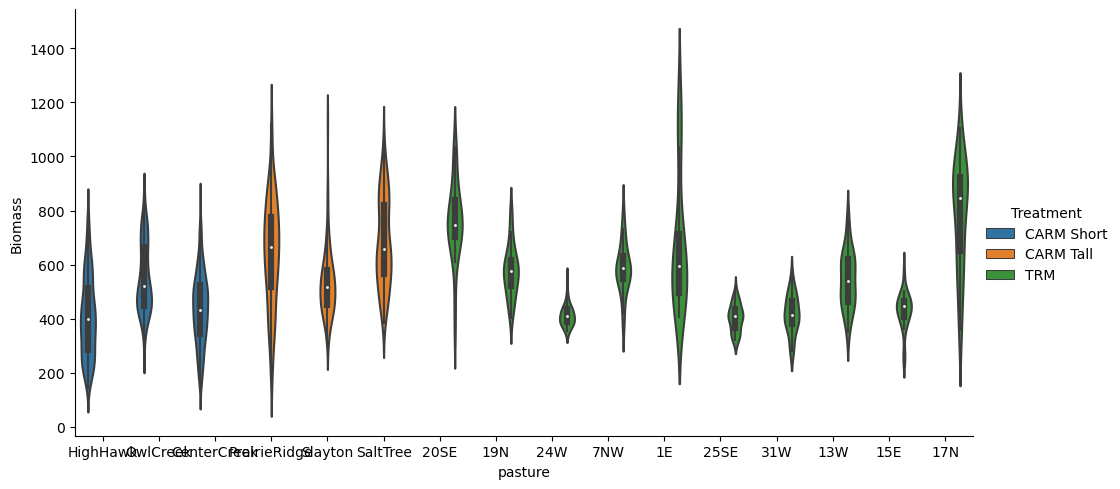

In [175]:
sns.catplot(kind='violin', y='Biomass', x='pasture', hue='Treatment', 
            data=df_10ac[df_10ac['date'] == pd.to_datetime('2024-06-20')].sort_values('Treatment'), 
            aspect=2.0, sharex=False)

In [185]:
import dask.dataframe as dd

df_10ac_past = df_10ac.drop(columns='subpasture')
# Convert Pandas DataFrame to Dask (npartitions should match CPU cores)
ddf = dd.from_pandas(df_10ac_past, npartitions=48)


In [186]:
df_10ac_var = ddf.groupby(['pasture', 'date']).apply(lambda data: np.var(data) / (np.mean(data)**2), meta=df_10ac_past).compute()

/project/cper_neon_aop/conda_envs/hls_nrt_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3417: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
2026-04-07 12:12:40,127 - distributed.worker - WARNING - Compute Failed
Key:       ('lambda-b6ab3c491481d1caea827ca68eba5000', 2)
Function:  subgraph_callable-2e38b8cb-a603-4e2a-bd6d-4a794340
args:      (                       date             y  ...   Treatment  _partitions
1073    2024-01-01 00:00:00  4.517819e+06  ...  CARM Short            2
1074    2024-01-01 00:00:00  4.517819e+06  ...  CARM Short            2
1075    2024-01-01 00:00:00  4.517819e+06  ...  CARM Short            2
1076    2024-01-01 00:00:00  4.517819e+06  ...  CARM Short            2
1077    2024-01-01 00:00:00  4.517819e+06  ...  CARM Short 

ValueError: The columns in the computed data do not match the columns in the provided metadata
  Extra:   []
  Missing: ['Past_Name', 'Treatment', 'date', 'pasture']

2026-04-07 12:12:43,395 - distributed.worker - WARNING - Compute Failed
Key:       ('lambda-8742334b41a234c62301988c9420a12e', 34)
Function:  subgraph_callable-08f98e6e-5743-4f51-ac0b-8a27b72a
args:      (                       date             y  ...  Treatment  _partitions
10480   2024-01-06 00:00:00  4.519499e+06  ...        TRM           34
10481   2024-01-06 00:00:00  4.519499e+06  ...        TRM           34
10482   2024-01-06 00:00:00  4.519499e+06  ...        TRM           34
10483   2024-01-06 00:00:00  4.519499e+06  ...        TRM           34
10484   2024-01-06 00:00:00  4.519499e+06  ...        TRM           34
...                     ...           ...  ...        ...          ...
719407  2024-12-31 00:00:00  4.521179e+06  ...  CARM Tall           34
719408  2024-12-31 00:00:00  4.521179e+06  ...  CARM Tall           34
719409  2024-12-31 00:00:00  4.521179e+06  ...  CARM Tall           34
719410  2024-12-31 00:00:00  4.521179e+06  ...  CARM Tall           34
719411  2024-1

In [182]:
df_10ac_var

,y,x,Biomass,BARE,CP,NDVI,Biomass_count,spatial_ref
npartitions=48,,,,,,,,
,float64,float64,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
